# 05 — Side-by-side comparison

This notebook does not introduce a new method. It re-imports the four distance
functions from `utils/distances.py` — the finished versions of the algorithms derived
step by step in notebooks 01-04 — and applies all of them to the same
`reference -> variant` pairs, so the differences in behaviour become visible in one
table and one chart.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

from data.synthetic import generate_dataset
from utils import plotting
from utils.distances import dtw_distance, edr_distance, erp_distance, feature_distances

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

In [2]:
dataset = generate_dataset()
reference = dataset["reference"]
variants = [name for name in dataset if name != "reference"]

# Parameters of the two parameterised methods, as chosen in notebooks 02 and 03.
EPS = 0.5  # EDR matching tolerance
G = 0.0    # ERP gap element

In [3]:
# One row per variant, one column per method. This takes a few seconds:
# three O(n*m) DP matrices per variant, in plain Python loops.
feature_dist = feature_distances(dataset)

comparison = pd.DataFrame({
    "DTW": [dtw_distance(reference, dataset[v]) for v in variants],
    "EDR": [edr_distance(reference, dataset[v], EPS) for v in variants],
    "ERP": [erp_distance(reference, dataset[v], G) for v in variants],
    "feature_distance": [feature_dist[v] for v in variants],
}, index=variants)
comparison.index.name = "variant"
comparison

,DTW,EDR,ERP,feature_distance
variant,,,,
amplitude_scaled,273.333,222.000,393.901,5.978
resampled,23.310,90.000,120.185,1.399
noisy,122.133,107.000,124.208,5.802
phase_shifted,83.347,80.000,130.045,1.285
reversed,100.358,146.000,187.117,0.000
unrelated,317.349,240.000,340.040,5.398


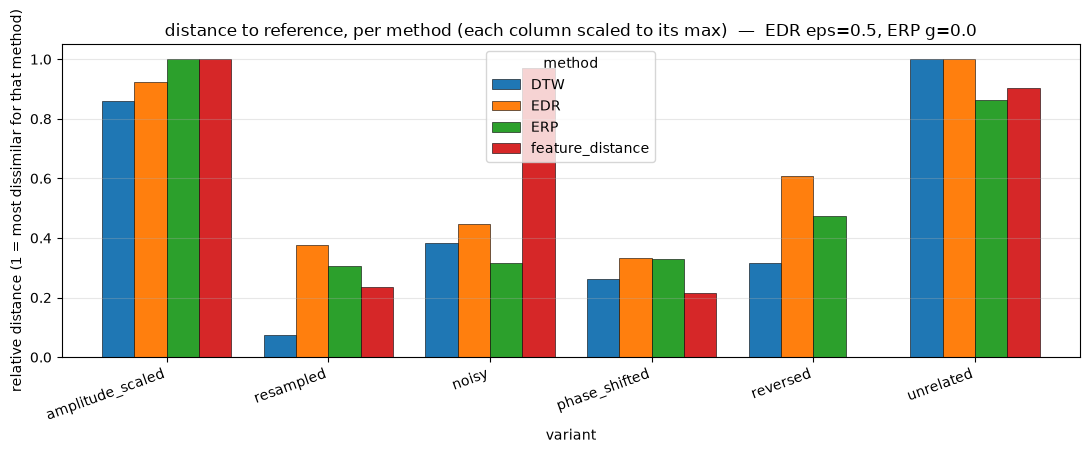

In [4]:
# The four columns live on completely different scales (edit counts vs. summed
# magnitudes vs. a z-score distance), so scale each column to its own maximum
# before plotting. Only the *shape* of each group is meaningful, not the height.
scaled = comparison / comparison.max()
plotting.plot_distance_bars(
    scaled,
    title=f"distance to reference, per method (each column scaled to its max)"
          f"  —  EDR eps={EPS}, ERP g={G}",
    ylabel="relative distance (1 = most dissimilar for that method)",
)

In [5]:
# Ranks make the disagreements easier to read than the raw numbers:
# 1 = most similar to the reference, 6 = most dissimilar, per method.
ranks = comparison.rank().astype(int)
ranks

,DTW,EDR,ERP,feature_distance
variant,,,,
amplitude_scaled,5,5,6,6
resampled,1,2,1,3
noisy,4,3,2,5
phase_shifted,2,1,3,2
reversed,3,4,4,1
unrelated,6,6,5,4


## What the chart shows

**Where all four agree.** `resampled` and `phase_shifted` are the two most similar
variants for every method. The three DP methods get there by warping the time axis; the
feature approach gets there because summary statistics barely change when a signal is
stretched or shifted. `unrelated` and `amplitude_scaled` sit at the dissimilar end
everywhere — though for different reasons, and in a different order: ERP punishes the
doubled amplitude hardest of all (rank 6, ahead of `unrelated`), because it pays real
magnitudes for matches *and* gaps, while DTW has the two nearly tied and EDR keeps the
amplitude change bounded by its flat cost of 1 per mismatch.

**Where they disagree — `reversed`.** This is the clearest split in the table. DTW, EDR
and ERP all separate it from the reference by a wide margin (100.4 / 146 / 187.1, three
to six times the `resampled` cost), because their monotone alignment paths cannot map a
rising ramp onto a falling one. The feature approach gives it a distance of **exactly
0**: all twelve features (moments, zero-crossing rate, FFT magnitudes, autocorrelation)
are invariant under time reversal, so the two series are literally the same point in
feature space — it is ranked the *most similar* variant of all.

**Where they disagree — `noisy`.** The feature approach ranks `noisy` as *more*
dissimilar than the structurally `unrelated` step signal, because additive noise moves
kurtosis, zero-crossing rate and the autocorrelation coefficients a long way, while the
step signal happens to land near the reference on several of those features. All three
DP methods rank it the other way round.

**Practical reading.** Use DTW when speed differences matter and magnitudes should be
compared honestly; EDR when the data is spiky and a tolerance band is a natural notion of
"equal" (but budget time for tuning `eps`); ERP when you need a real metric for indexing
or clustering; and features when you have many long series and need something cheap,
cacheable and classifier-ready — provided the properties you care about actually survive
the summarisation.